# Chapter 12: Credit for Consequences

The draft step earns no immediate reward. The review step produces the eventual benefit. If the controller learns only from immediate outcomes, it may never give preparation the credit it deserves. If it waits for every complete episode, it may learn slowly or fail to use partial traces.

This notebook puts three credit rules beside the same trajectory. Monte Carlo uses the discounted later return. TD(0) bootstraps from the next state's current value. Eligibility traces spread a later TD error backward through recently visited states. The changed case marks the end as truncation rather than true termination, exposing the value that can be lost when those two boundaries are confused.

**Outcome:** Compare Monte Carlo, TD(0), and accumulating TD(lambda) updates on one trajectory.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

For a complete trajectory, the return target is G_t=r_t+gamma G_(t+1), with terminal continuation zero. For a truncated trace, this implementation initializes the final continuation from the supplied value estimate instead. The backward recurrence makes that distinction visible in every earlier target.

Monte Carlo updates V(s_t) by alpha[G_t-V(s_t)]. TD(0) uses delta_t=r_t+gamma V(s_(t+1))-V(s_t), replacing the next value with zero only at true terminal transition. Accumulating TD(lambda) first adds one to the current state's eligibility, updates every value by alpha delta_t e_t(s), then decays eligibility by gamma lambda.

All three rules receive the same reward sequence and initial values, but their online updates differ. A state revisited within the trace can accumulate eligibility or receive multiple updates. This notebook implements one sequential pass, not an asymptotic convergence experiment. Lambda controls how far a later error reaches backward; it does not manufacture missing future rewards.

How this relates to Equation (12.4). The chapter writes the forward view: each visited state moves toward its lambda-return. This notebook implements the backward view, accumulating eligibility traces applied online during one pass. For a terminal episode the two give identical updates when the updates are offline, meaning the value estimates are held fixed during the episode and the summed increments are applied at the end. With online updates, as here, they still agree exactly when no state repeats within the episode, because every update touches only states already visited and no later TD error reads them. When a state repeats, online updates change estimates that later errors use, and the result can differ from the Equation (12.4) update. The default trajectory has no repeated state, so its values 0.4 and 0.5 equal the forward-view updates.

## A calculation you can run

Give the ordered state list, rewards, initial values, discount, learning rate, lambda, and exact terminal flag. The state list must have one more element than the reward list. Values must exist for every named state. The code computes backward return targets, then applies each update rule to its own independent copy of the initial value map.

The return plot shows the target associated with each transition, while the trace-error plot shows the online TD errors used by eligibility updates. Consult the three final value maps to compare credit assignment. In the changed case the final state's estimate is 2 and terminal is false. Predict how that bootstrap changes the targets before running the calculation.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 12
inputs = {'states': ['draft', 'review', 'done'],
 'rewards': [0, 1],
 'discount': 1,
 'learning_rate': 0.5,
 'lambda': 0.8,
 'terminal': True,
 'values': {'draft': 0, 'review': 0, 'done': 0}}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 12: trajectory-credit
How should a late consequence change values assigned to earlier states?
Evidence: constructed teaching example

Calculated quantities:
{
  "returns": [
    1.0,
    1.0
  ],
  "monte_carlo_values": {
    "review": 0.5,
    "done": 0.0,
    "draft": 0.5
  },
  "td_zero_values": {
    "review": 0.5,
    "done": 0.0,
    "draft": 0.0
  },
  "td_lambda_values": {
    "review": 0.5,
    "done": 0.0,
    "draft": 0.4
  },
  "bootstrap_value": 0
}

Interpretation:
All three estimators see the same rewards. A truncated trajectory retains its supplied final bootstrap value; a terminal trajectory sets that continuation to zero.

Assumptions:
- One sequential pass with accumulating eligibility traces.
- Initial values, discount, step size, and terminal status are declared.

Limitations:
- This finite update does not demonstrate convergence.
- Bootstrapping trades dependence on later observations for dependence on current estimates.

Execution: completed locally; cons

Default returns are [1,1]. With alpha=0.5, Monte Carlo assigns draft and review values 0.5. TD(0) updates draft from a zero next value, leaving it at zero, then assigns review 0.5. TD(lambda) carries the later error back with eligibility 0.8, giving draft 0.4 and review 0.5.

In the changed truncated case, final bootstrap is 2. Returns become [3,3]. Treating that trace as terminal would incorrectly erase the supplied continuation estimate. Whether 2 is a good estimate is a separate question; the credit arithmetic simply makes its dependence explicit.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


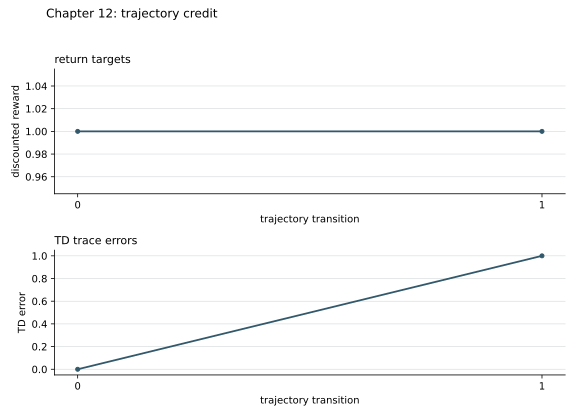

In [3]:
display(SVG(figure_svg(report)))

**Figure 12.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

Bootstrapping can propagate a bad value estimate. Monte Carlo avoids that particular dependence in complete episodes, but it depends on the observed later return and can have high sampling variability. Neither target dominates in every setting.

The terminal flag is especially important in limited-budget logs. An observation window ending is not proof that the underlying task terminated. Setting terminal true after a timeout can systematically suppress continuation value. Setting it false at actual termination can add imaginary future reward.

Trace conventions also matter. Replacing traces and accumulating traces are different algorithms when states repeat. This implementation uses accumulating traces. Compare it with equations under that convention, and avoid claiming convergence from one pass over a short supplied trajectory. Learning-rate schedules, visitation, and process assumptions would need their own study.

Chapter 12: trajectory-credit
How should a late consequence change values assigned to earlier states?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "returns": [
    3.0,
    3.0
  ],
  "monte_carlo_values": {
    "review": 1.5,
    "done": 2.0,
    "draft": 1.5
  },
  "td_zero_values": {
    "review": 1.5,
    "done": 2.0,
    "draft": 0.0
  },
  "td_lambda_values": {
    "review": 1.5,
    "done": 2.0,
    "draft": 1.2
  },
  "bootstrap_value": 2.0
}

Interpretation:
All three estimators see the same rewards. A truncated trajectory retains its supplied final bootstrap value; a terminal trajectory sets that continuation to zero.

Assumptions:
- One sequential pass with accumulating eligibility traces.
- Initial values, discount, step size, and terminal status are declared.

Limitations:
- This finite update does not demonstrate convergence.
- Bootstrapping trades dependence on later observations for dependence on current estimates.

Execution: completed l

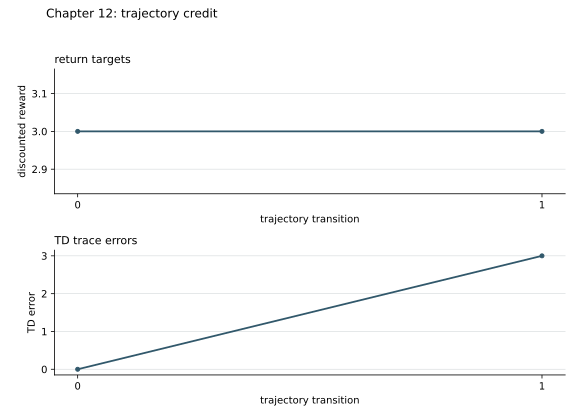

In [4]:
changed_inputs = {'states': ['draft', 'review', 'done'],
 'rewards': [0, 1],
 'discount': 1,
 'learning_rate': 0.5,
 'lambda': 0.8,
 'terminal': False,
 'values': {'draft': 0, 'review': 0, 'done': 2}}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 12.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer case sets lambda to zero. Accumulating TD(lambda) then updates only the currently eligible state before immediate decay, so its final values should agree with TD(0) under the same sequential convention. This is an independent structural check rather than a visual similarity claim.

For local use, preserve reward timing and state identity, and mark whether the final boundary is real termination or missing observation. If the final value is a fitted estimate, record its provenance. A trajectory-credit report should show targets and bootstrap assumptions as well as updated values, so a surprising change can be traced to evidence rather than hidden continuation.

In [5]:
transfer_inputs = {'states': ['a', 'b', 'c', 'd'],
 'rewards': [1, 0, 2],
 'discount': 0.9,
 'learning_rate': 0.2,
 'lambda': 0,
 'terminal': True,
 'values': {'a': 0, 'b': 1, 'c': 0, 'd': 0}}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 12: trajectory-credit
How should a late consequence change values assigned to earlier states?
Evidence: constructed transfer example

Calculated quantities:
{
  "returns": [
    2.62,
    1.8,
    2.0
  ],
  "monte_carlo_values": {
    "d": 0.0,
    "c": 0.4,
    "a": 0.524,
    "b": 1.16
  },
  "td_zero_values": {
    "d": 0.0,
    "c": 0.4,
    "a": 0.38,
    "b": 0.8
  },
  "td_lambda_values": {
    "d": 0.0,
    "c": 0.4,
    "a": 0.38,
    "b": 0.8
  },
  "bootstrap_value": 0
}

Interpretation:
All three estimators see the same rewards. A truncated trajectory retains its supplied final bootstrap value; a terminal trajectory sets that continuation to zero.

Assumptions:
- One sequential pass with accumulating eligibility traces.
- Initial values, discount, step size, and terminal status are declared.

Limitations:
- This finite update does not demonstrate convergence.
- Bootstrapping trades dependence on later observations for dependence on current estimates.

Execution: co

## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **states:** Trajectory state identifiers, one more than reward count.
- **rewards:** Finite observed immediate rewards.
- **discount:** Gamma in [0,1].
- **learning_rate:** Step size in [0,1].
- **lambda:** Trace decay parameter in [0,1].
- **terminal:** Exact boolean distinguishing true termination from truncation.
- **values:** Initial finite value for every trajectory state.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch12.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 12: trajectory-credit
How should a late consequence change values assigned to earlier states?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "returns": [
    2.62,
    1.8,
    2.0
  ],
  "monte_carlo_values": {
    "d": 0.0,
    "c": 0.4,
    "a": 0.524,
    "b": 1.16
  },
  "td_zero_values": {
    "d": 0.0,
    "c": 0.4,
    "a": 0.38,
    "b": 0.8
  },
  "td_lambda_values": {
    "d": 0.0,
    "c": 0.4,
    "a": 0.38,
    "b": 0.8
  },
  "bootstrap_value": 0
}

Interpretation:
All three estimators see the same rewards. A truncated trajectory retains its supplied final bootstrap value; a terminal trajectory sets that continuation to zero.

Assumptions:
- One sequential pass with accumulating eligibility traces.
- Initial values, discount, step size, and terminal status are declared.

Limitations:
- This finite update does not demonstrate convergence.
- Bootstrapping trades dependence on later observations for dependence on c

## Questions

1. Compute default trace update to draft.

2. What are changed return targets?

3. What should lambda = 0 match?

Answers: [separate solutions](../solutions/ch12.md). Try the calculation before opening them.

## Summary

Credit rules differ in which future information they use. Monte Carlo follows the observed return, TD(0) bootstraps locally, and eligibility traces spread later errors through recent states. Terminal versus truncated boundaries alter continuation. The default is hand-checkable, the changed case exposes bootstrap dependence, and lambda zero checks the transfer identity. One finite update demonstrates mechanics, not convergence or reliable learning in a deployed agent.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-12-trajectory-credit`](../skills/maa-12-trajectory-credit/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 12.1

![Equation 12.1](../assets/math/d6697e3cc821de210964.svg)

Equation (12.1) drags each state's estimate toward the return that actually followed it.

Take the gap between what happened and what was predicted, keep a fraction of it, and add that to the prediction.

LaTeX source, preserved for inspection:

```latex
\hat V_{t+1}(x_t) \;=\; \hat V_t(x_t) \;+\; \alpha\big[\operatorname{Ret}_t - \hat V_t(x_t)\big].
\tag{12.1}
```

### Equation 12.2

![Equation 12.2](../assets/math/cc2c6da6e8a537b237b5.svg)

Equation (12.2) measures how much the agent's own opinion changed between one step and the next.

Compare what was predicted from here against the reward received plus what is predicted from there.

LaTeX source, preserved for inspection:

```latex
\delta_t \;=\; r_t \;+\; \gamma\,\hat V_t(x_{t+1}) \;-\; \hat V_t(x_t).
\tag{12.2}
```

### Equation 12.3

![Equation 12.3](../assets/math/bea157a42325799a5a1c.svg)

Equation (12.3) moves each estimate toward the estimate that came immediately after it.

Nudge the earlier prediction in the direction its own successor disagreed with it.

LaTeX source, preserved for inspection:

```latex
\hat V_{t+1}(x_t) \;=\; \hat V_t(x_t) \;+\; \alpha\,\delta_t.
\tag{12.3}
```

### Equation 12.4

![Equation 12.4](../assets/math/3def44a4bcac72579801.svg)

Equation (12.4) combines geometrically weighted intermediate targets with the remaining weight on the complete terminal return.

Weight intermediate lookahead targets geometrically, then place all remaining weight on the realized return through termination.

LaTeX source, preserved for inspection:

```latex
\operatorname{Ret}^{\lambda}_t \;=\; (1-\lambda)\sum_{k=1}^{N-t-1}\lambda^{\,k-1}\Big[\textstyle\sum_{j=0}^{k-1}\gamma^{\,j} r_{t+j} \;+\; \gamma^{\,k}\hat V_t(x_{t+k})\Big] \;+\; \lambda^{N-t-1}\operatorname{Ret}_t.
\tag{12.4}
```